In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score
import pickle





In [2]:
df = pd.read_csv("modern_laptop_dataset_5000.csv")
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Acer,Ultrabook,14.0,Full HD,Intel Core i5,8,256GB SSD,Intel UHD,Windows 10,1.50,32792
1,Dell,Notebook,14.0,Full HD,Apple M1,32,256GB SSD,Nvidia GTX 1650,Windows 10,1.95,91804
2,Apple,Notebook,16.0,Full HD,Intel Core i5,16,512GB SSD,AMD Radeon,macOS,1.99,119166
3,Acer,Gaming,15.6,Full HD,Apple M2,32,256GB SSD,AMD Radeon,Windows 11,2.22,95028
4,HP,Ultrabook,16.0,Full HD,AMD Ryzen 7,32,512GB SSD,Intel UHD,Linux,2.04,77910
...,...,...,...,...,...,...,...,...,...,...,...
4995,Dell,Notebook,13.3,Full HD,Intel Core i7,8,1TB SSD,Intel Iris,Windows 10,2.28,73634
4996,Dell,Workstation,14.0,Retina,Intel Core i7,8,256GB SSD,Intel Iris,macOS,1.60,52995
4997,Lenovo,Gaming,13.3,4K,AMD Ryzen 7,8,256GB SSD,Nvidia RTX 3050,macOS,2.13,77142
4998,Acer,Ultrabook,14.0,Retina,Intel Core i5,16,512GB SSD,Intel UHD,macOS,2.38,47827


In [3]:
df.shape

(5000, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           5000 non-null   object 
 1   TypeName          5000 non-null   object 
 2   Inches            5000 non-null   float64
 3   ScreenResolution  5000 non-null   object 
 4   Cpu               5000 non-null   object 
 5   Ram               5000 non-null   int64  
 6   Memory            5000 non-null   object 
 7   Gpu               5000 non-null   object 
 8   OpSys             5000 non-null   object 
 9   Weight            5000 non-null   float64
 10  Price             5000 non-null   int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 429.8+ KB


In [5]:
df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

In [6]:
df.groupby("Company")["TypeName"].value_counts()

Company  TypeName   
Acer     Notebook       186
         Ultrabook      178
         Gaming         171
         Workstation    168
Apple    Gaming         193
         Ultrabook      186
         Notebook       181
         Workstation    160
Asus     Workstation    210
         Ultrabook      194
         Notebook       186
         Gaming         166
Dell     Gaming         191
         Notebook       188
         Ultrabook      181
         Workstation    177
HP       Gaming         201
         Notebook       198
         Ultrabook      158
         Workstation    154
Lenovo   Gaming         191
         Ultrabook      177
         Workstation    176
         Notebook       171
MSI      Workstation    180
         Notebook       170
         Gaming         162
         Ultrabook      146
Name: count, dtype: int64

In [7]:
df.dtypes

Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                   int64
Memory               object
Gpu                  object
OpSys                object
Weight              float64
Price                 int64
dtype: object

In [8]:
df.isna().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [9]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Acer,Ultrabook,14.0,Full HD,Intel Core i5,8,256GB SSD,Intel UHD,Windows 10,1.50,32792
1,Dell,Notebook,14.0,Full HD,Apple M1,32,256GB SSD,Nvidia GTX 1650,Windows 10,1.95,91804
2,Apple,Notebook,16.0,Full HD,Intel Core i5,16,512GB SSD,AMD Radeon,macOS,1.99,119166
3,Acer,Gaming,15.6,Full HD,Apple M2,32,256GB SSD,AMD Radeon,Windows 11,2.22,95028
4,HP,Ultrabook,16.0,Full HD,AMD Ryzen 7,32,512GB SSD,Intel UHD,Linux,2.04,77910


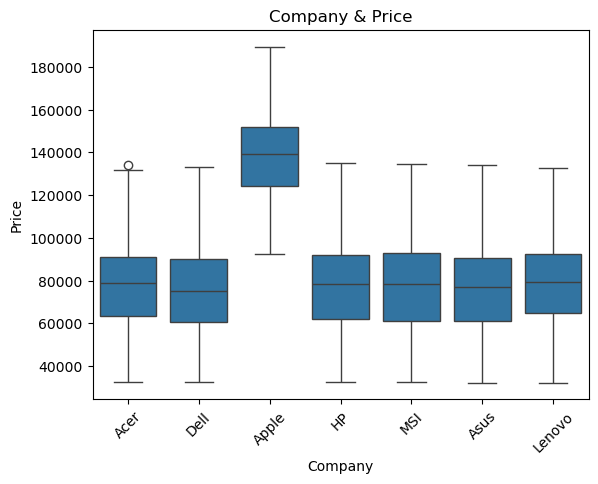

In [10]:
sns.boxplot(x = "Company", y = "Price", data = df)
plt.xticks(rotation = 45)
plt.title("Company & Price")
plt.show()

In [11]:
q1 = df['Price'].quantile(0.25)
q3 = df['Price'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr

df['Price'] = np.where(df['Price'] > upper, upper, df['Price'])

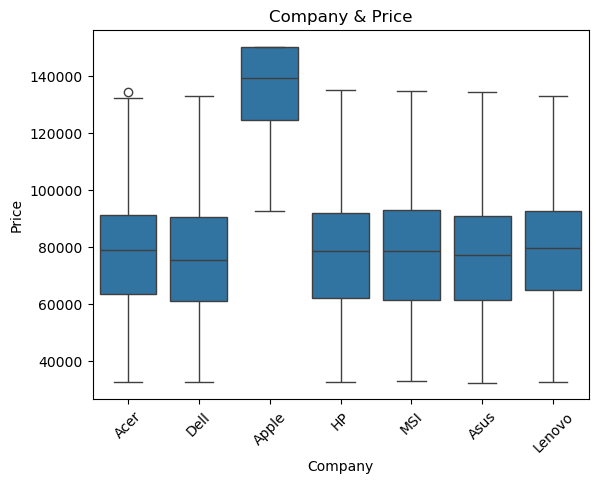

In [12]:
sns.boxplot(x = "Company", y = "Price", data = df)
plt.xticks(rotation = 45)
plt.title("Company & Price")
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

encoders = {}  # dict to store one encoder per categorical column

for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  # save encoder for later use

In [14]:

X = df.drop('Price', axis=1)
y = np.log1p(df['Price'])


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [16]:
Scaling_Features = StandardScaler()
X_train = Scaling_Features.fit_transform(X_train)
X_test = Scaling_Features.transform(X_test)

In [17]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)
y_pred

array([11.18660042, 11.47929392, 11.64087855, 11.23059804, 11.07095067,
       11.32788278, 11.16981641, 11.25669695, 11.17532269, 11.35798677,
       11.36719961, 11.44103208, 11.36625301, 11.15495018, 11.11174017,
       11.45047617, 11.19370927, 11.49460159, 11.25107081, 11.16369531,
       10.8262795 , 11.07060768, 11.08340776, 11.25080365, 11.30871523,
       11.29846273, 11.61656327, 11.16360563, 11.14993935, 11.03772173,
       11.21854377, 11.21829758, 11.08931447, 11.18546834, 11.19207574,
       11.37968501, 11.29287311, 11.16689216, 11.35074483, 11.13890501,
       11.12074222, 11.31607334, 11.48284961, 11.49332779, 11.16705142,
       11.50941408, 11.39487043, 10.9065445 , 11.46242615, 11.33701012,
       11.48522334, 11.63547206, 11.28021642, 11.44677022, 11.41841131,
       11.43878167, 11.49400223, 11.27872338, 11.24478663, 11.63068289,
       11.40761264, 11.28615804, 11.33242236, 11.43101688, 11.196513  ,
       10.93040843, 11.52452054, 11.5661029 , 11.71937962, 11.35

In [19]:
mse = mean_squared_error(y_test, y_pred)
print('R2 score:',r2_score(y_test,y_pred))
print("Mean Squared Error:", mse)

R2 score: 0.26510706012350527
Mean Squared Error: 0.08514715463319292


In [20]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1  # use all cores
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print('MSE:', mean_squared_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))


MSE: 0.004512208782574461
R2: 0.9610557699567566


In [21]:
import pickle
columns = X.columns.tolist() 

saved_objects = {
    "model": model,
    "scaler": Scaling_Features,
    "columns": columns,
    "encoders": encoders
}

with open("model.pkl", "wb") as f:
    pickle.dump(saved_objects, f)